In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
df = pd.read_csv('SeoulBikeData.csv', encoding='unicode_escape') 
df.head()


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [5]:
print(df.info())
print(df.describe())
print(df.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [9]:
# Manually split the date
date_split = df['Date'].str.split('/', expand=True)

# Assign to new columns
df['Day'] = date_split[0].astype(int)
df['Month'] = date_split[1].astype(int)
df['Year'] = date_split[2].astype(int)

# Optional: Verify
df[['Date', 'Day', 'Month', 'Year']].head()


,Date,Day,Month,Year
0,01/12/2017,1,12,2017
1,01/12/2017,1,12,2017
2,01/12/2017,1,12,2017
3,01/12/2017,1,12,2017
4,01/12/2017,1,12,2017


In [11]:
# Manually split the 'Date' column
date_split = df['Date'].str.split('/', expand=True)

# Assign new columns with correct format: assuming format is DD/MM/YYYY
df['Day'] = date_split[0].astype(int)
df['Month'] = date_split[1].astype(int)
df['Year'] = date_split[2].astype(int)

# Drop the original 'Date' column
df.drop('Date', axis=1, inplace=True)

# Verify changes
df.head()


,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Day,Month,Year
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017


In [15]:
# Clean column names: lowercase and replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.head()

,rented_bike_count,hour,temperature(°c),humidity(%),wind_speed_(m/s),visibility_(10m),dew_point_temperature(°c),solar_radiation_(mj/m2),rainfall(mm),snowfall_(cm),seasons,holiday,functioning_day,day,month,year
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,12,2017


In [17]:
print("Seasons:", df['seasons'].unique())
print("Holiday:", df['holiday'].unique())
print("Functioning Day:", df['functioning_day'].unique())


Seasons: ['Winter' 'Spring' 'Summer' 'Autumn']
Holiday: ['No Holiday' 'Holiday']
Functioning Day: ['Yes' 'No']


In [19]:
# Map season to 1–4
df['seasons'] = df['seasons'].map({
    'Winter': 1,
    'Spring': 2,
    'Summer': 3,
    'Autumn': 4
})

# Map holiday to 0–1
df['holiday'] = df['holiday'].map({
    'No Holiday': 0,
    'Holiday': 1
})

# Map functioning_day to 1–0
df['functioning_day'] = df['functioning_day'].map({
    'Yes': 1,
    'No': 0
})


In [21]:
df.head()

,rented_bike_count,hour,temperature(°c),humidity(%),wind_speed_(m/s),visibility_(10m),dew_point_temperature(°c),solar_radiation_(mj/m2),rainfall(mm),snowfall_(cm),seasons,holiday,functioning_day,day,month,year
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,0,1,1,12,2017
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,0,1,1,12,2017
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,0,1,1,12,2017
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,0,1,1,12,2017
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,0,1,1,12,2017


In [23]:
functioning_counts = df.groupby('functioning_day')['rented_bike_count'].mean()
print("\nAverage Rented Bike Count on Functioning vs Non-Functioning Days:\n", functioning_counts)



Average Rented Bike Count on Functioning vs Non-Functioning Days:
 functioning_day
0      0.000000
1    729.156999
Name: rented_bike_count, dtype: float64


In [25]:
holiday_counts = df.groupby('holiday')['rented_bike_count'].mean()
print("Average Rented Bike Count on Holidays vs Non-Holidays:\n", holiday_counts)


Average Rented Bike Count on Holidays vs Non-Holidays:
 holiday
0    715.228026
1    499.756944
Name: rented_bike_count, dtype: float64


In [27]:
non_functioning_one_bike = df[(df['functioning_day'] == 0) & (df['rented_bike_count'] == 1)]
count = non_functioning_one_bike.shape[0]
print(f"Number of rows where it's a non-functioning day and bike count is 1: {count}")


Number of rows where it's a non-functioning day and bike count is 1: 0


In [29]:
# Drop rows where functioning_day is 0
df = df[df['functioning_day'] == 1]

# Drop the functioning_day column
df.drop('functioning_day', axis=1, inplace=True)


C:\Users\Sanjam\AppData\Local\Temp\ipykernel_8716\1099618298.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('functioning_day', axis=1, inplace=True)


In [31]:
df.head()

,rented_bike_count,hour,temperature(°c),humidity(%),wind_speed_(m/s),visibility_(10m),dew_point_temperature(°c),solar_radiation_(mj/m2),rainfall(mm),snowfall_(cm),seasons,holiday,day,month,year
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,0,1,12,2017
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,0,1,12,2017
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,0,1,12,2017
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,0,1,12,2017
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,0,1,12,2017


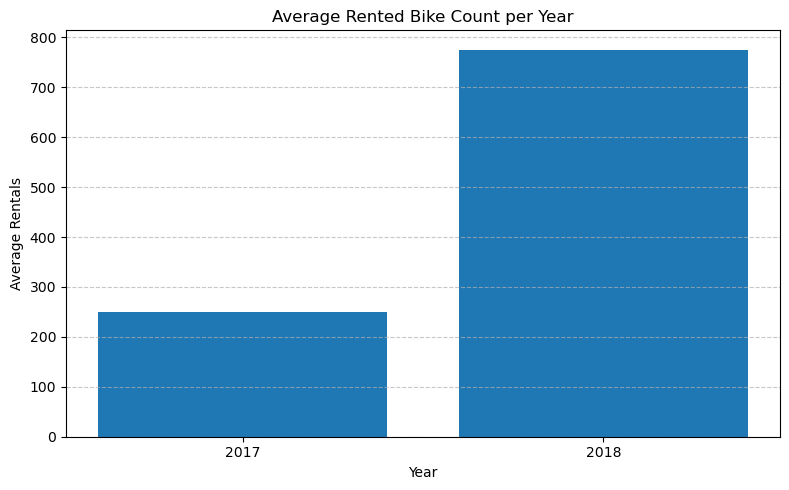

In [35]:
import matplotlib.pyplot as plt

# Group by year and calculate average
yearly_avg = df.groupby('year')['rented_bike_count'].mean()

# Plot
plt.figure(figsize=(8,5))
plt.bar(yearly_avg.index.astype(str), yearly_avg.values)

plt.title("Average Rented Bike Count per Year")
plt.xlabel("Year")
plt.ylabel("Average Rentals")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


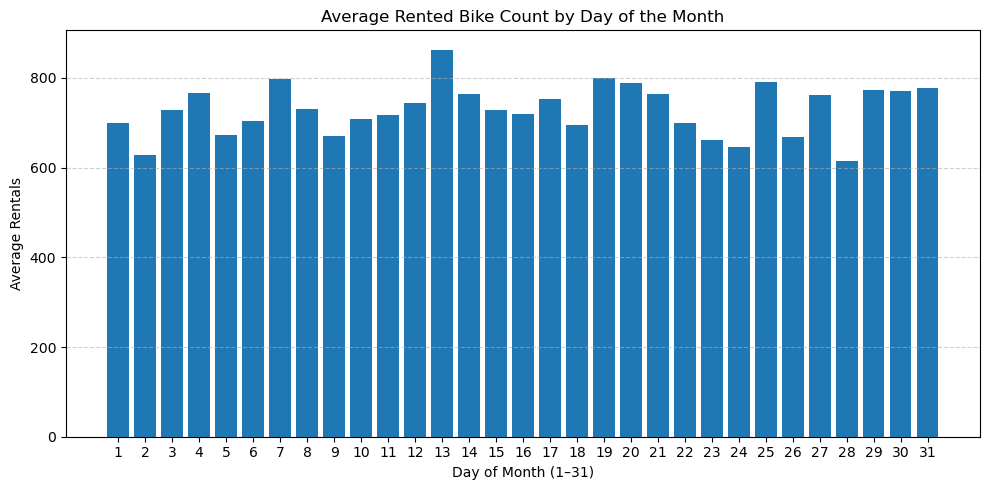

In [37]:
# Group by day of the month
daily_avg = df.groupby('day')['rented_bike_count'].mean()

# Plot
plt.figure(figsize=(10,5))
plt.bar(daily_avg.index, daily_avg.values)

plt.title("Average Rented Bike Count by Day of the Month")
plt.xlabel("Day of Month (1–31)")
plt.ylabel("Average Rentals")
plt.xticks(range(1, 32))  # Ensure all days are shown
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


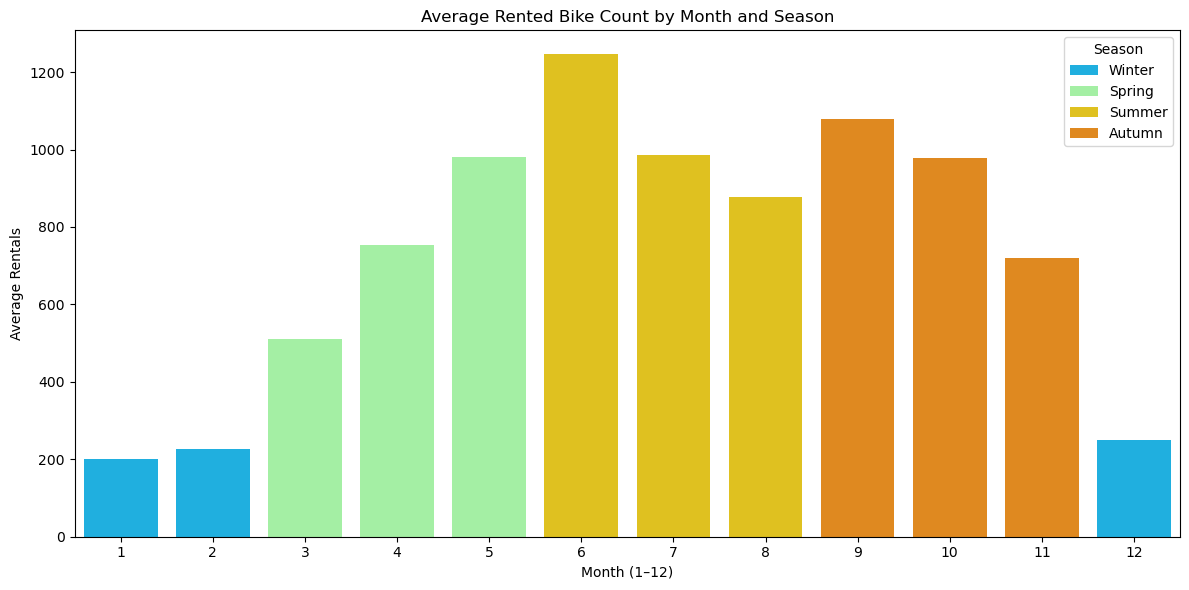

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by both month and season
combo = df.groupby(['month', 'seasons'])['rented_bike_count'].mean().reset_index()

# Map season numbers to names for readability
season_names = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Autumn'}
combo['season'] = combo['seasons'].map(season_names)

# Define custom colors for each season
season_palette = {
    'Winter': '#00BFFF',   # DeepSkyBlue
    'Spring': '#98FB98',   # PaleGreen
    'Summer': '#FFD700',   # Gold
    'Autumn': '#FF8C00'    # DarkOrange
}

# Plot with custom palette
plt.figure(figsize=(12,6))
sns.barplot(x='month', y='rented_bike_count', hue='season', data=combo, palette=season_palette)

plt.title("Average Rented Bike Count by Month and Season")
plt.xlabel("Month (1–12)")
plt.ylabel("Average Rentals")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


['rented_bike_count', 'hour', 'temperature(°c)', 'humidity(%)', 'wind_speed_(m/s)', 'visibility_(10m)', 'dew_point_temperature(°c)', 'solar_radiation_(mj/m2)', 'rainfall(mm)', 'snowfall_(cm)', 'seasons', 'holiday', 'day', 'month', 'year']


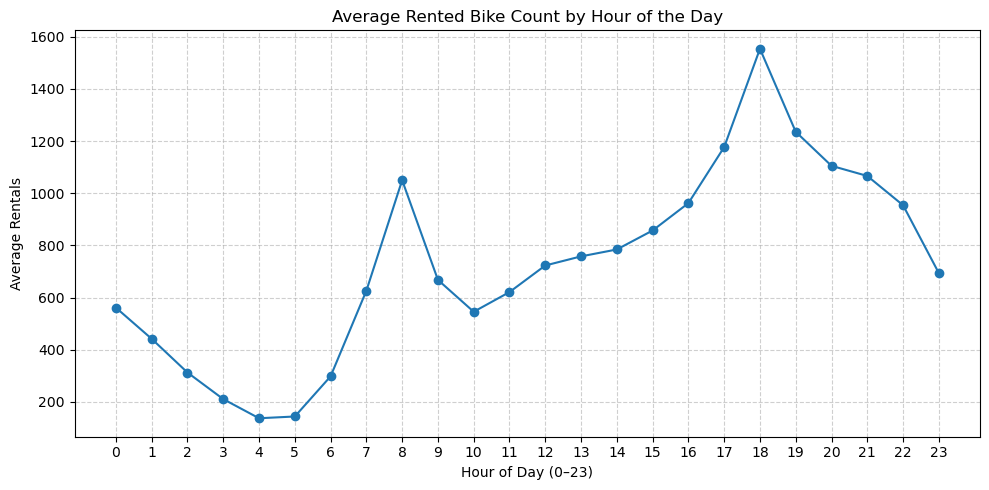

In [47]:
print(df.columns.tolist())
import matplotlib.pyplot as plt

# Group and calculate average per hour
hourly_avg = df.groupby('hour')['rented_bike_count'].mean().sort_index()

# Plot
plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', linestyle='-')

plt.title("Average Rented Bike Count by Hour of the Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Average Rentals")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


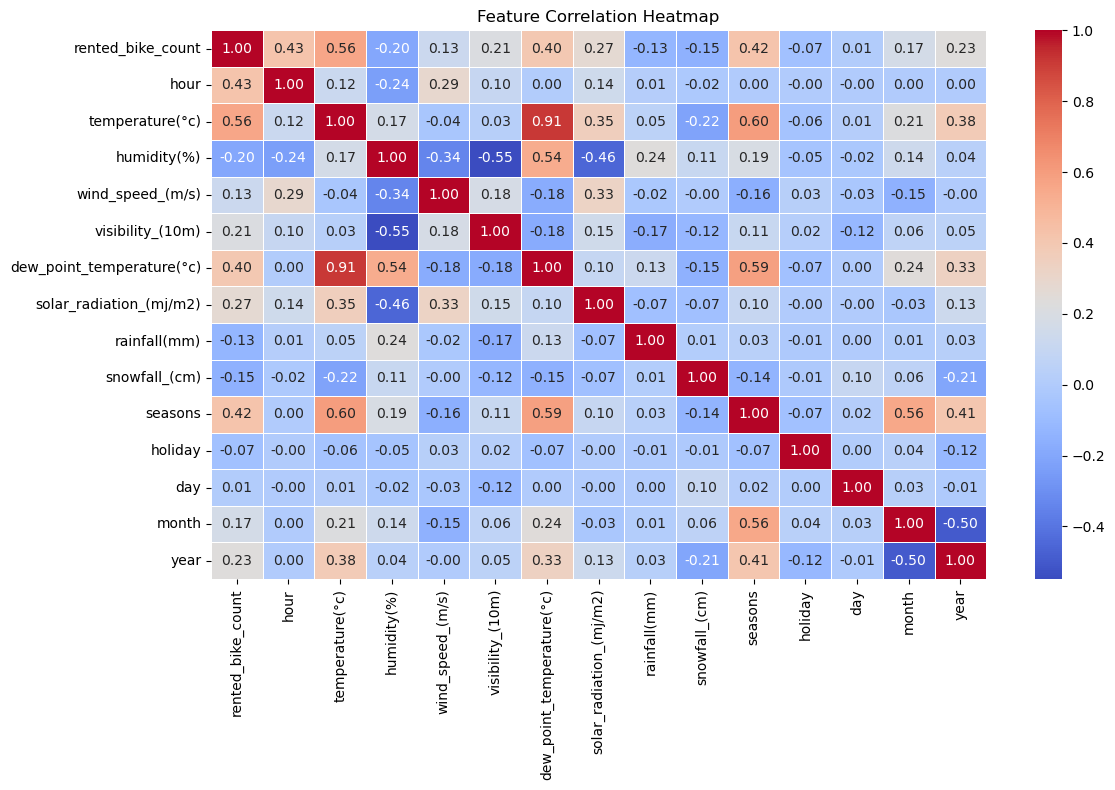

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [53]:
from sklearn.feature_selection import SelectKBest, f_regression

X = df.drop('rented_bike_count', axis=1)
y = df['rented_bike_count']

# Apply SelectKBest
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

# Show scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print(feature_scores)


                      Feature        Score
1             temperature(°c)  3922.056291
0                        hour  1868.347360
9                     seasons  1808.174463
5   dew_point_temperature(°c)  1614.523370
6     solar_radiation_(mj/m2)   686.190662
13                       year   481.443778
4            visibility_(10m)   399.531435
2                 humidity(%)   359.912719
12                      month   243.354078
8               snowfall_(cm)   199.105604
7                rainfall(mm)   142.373073
3            wind_speed_(m/s)   134.381256
10                    holiday    41.756703
11                        day     0.494525


In [55]:
features_to_drop = [
    'visibility_(10m)',
    'humidity(%)',
    'month',
    'snowfall_(cm)',
    'rainfall(mm)',
    'wind_speed_(m/s)',
    'holiday',
    'day'
]
df.drop(columns=features_to_drop, inplace=True)


C:\Users\Sanjam\AppData\Local\Temp\ipykernel_8716\3296943092.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=features_to_drop, inplace=True)


In [57]:
print("Data shape after feature selection:", df.shape)


Data shape after feature selection: (8465, 7)


In [59]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('rented_bike_count', axis=1)
y = df['rented_bike_count']

# Split data (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (6348, 6)
Test set shape: (2117, 6)


In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print results
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")


R² Score: 0.5260
Mean Squared Error: 187211.11
Root Mean Squared Error: 432.68
